<a href="https://colab.research.google.com/github/beyonddbold-ux/ML-Models/blob/main/51_Shruti_Rajput.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Problem Statement: Estimate the Loan Amount given a set of independent variables**

Step 1: Import Data

Step 2: Data Cleaning
a. Check for Duplicates
b. Check for Missing Values
c. Check for Outliers

Step 3: Data Pre Processing
Handle Categorical Columns - Label Encoding or One Hot Encoding

Step 4: Exploratory Data Analysis
a. Descriptive Statistics
b. Perform Hypothesis Testing
c. Correlation Matrix

Step 5: Fit the Machine Learning Algorithm
a. Scaling of the Data using Standard Scaler, Min Max Scaler or Robust Scaler
b. Train and Test Split is performed
c. Fit the Machine Learning Model

Step 6: Perform the Model Diagnostics
a. Extract the Predicted Values
b. Test for Model Assumptions (Assumption differs for each ML Model)

**Step** **1: Import Data**

In [24]:
import pandas as pd
df=pd.read_excel('/content/Loan_amount.xlsx')

In [25]:
#Checking if the data has been imported correctly
df.head()

,Loan_ID,LoanAmount,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,Loan_Amount_Term,Credit_History,Property_Area
0,LP001002,120.0,1,0,0,1,0,5849,0.0,360,1,1
1,LP001003,128.0,1,1,1,1,0,4583,1508.0,360,1,3
2,LP001005,66.0,1,1,0,1,1,3000,0.0,360,1,1
3,LP001006,120.0,1,1,0,2,0,2583,2358.0,360,1,1
4,LP001008,141.0,1,0,0,1,0,6000,0.0,360,1,1


In [26]:
df.tail()

,Loan_ID,LoanAmount,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,Loan_Amount_Term,Credit_History,Property_Area
559,LP002978,71.0,2,0,0,1,0,2900,0.0,360,1,3
560,LP002979,40.0,1,1,3,1,0,4106,0.0,180,1,3
561,LP002983,253.0,1,1,1,1,0,8072,240.0,360,1,1
562,LP002984,187.0,1,1,2,1,0,7583,0.0,360,1,1
563,LP002990,133.0,2,0,0,1,1,4583,0.0,360,0,2


**Step 2: Data Cleaning**

a. Check for Duplicates


In [27]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
559,False
560,False
561,False
562,False


There are no duplicates in the given data

b. Check for Missing Values

In [28]:
df.isnull()

,Loan_ID,LoanAmount,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,Loan_Amount_Term,Credit_History,Property_Area
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
559,False,False,False,False,False,False,False,False,False,False,False,False
560,False,False,False,False,False,False,False,False,False,False,False,False
561,False,False,False,False,False,False,False,False,False,False,False,False
562,False,False,False,False,False,False,False,False,False,False,False,False


In [29]:
df.isnull().sum()

,0
Loan_ID,0
LoanAmount,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
Loan_Amount_Term,0


There are no missing values in the given data

c. Check for Outliers

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns


<Axes: ylabel='LoanAmount'>

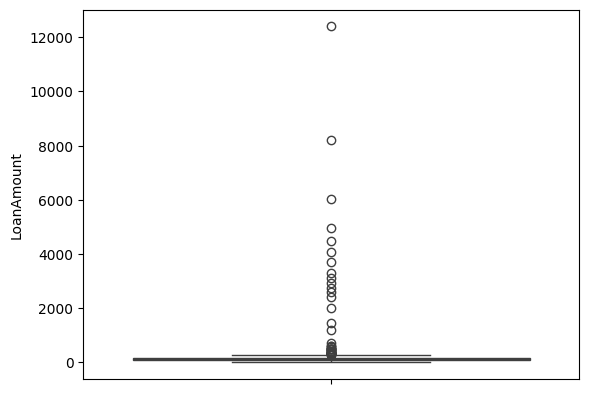

In [31]:
sns.boxplot(df['LoanAmount'])

<Axes: ylabel='ApplicantIncome'>

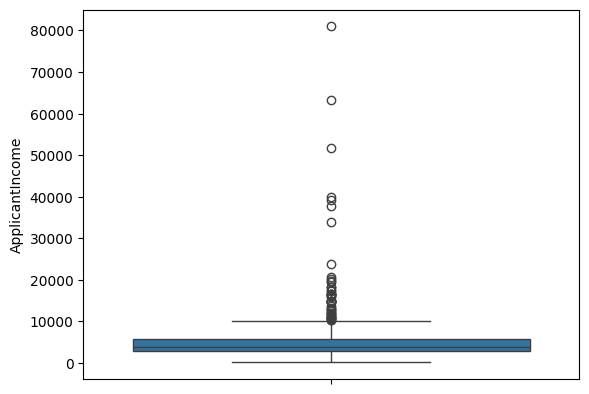

In [32]:
sns.boxplot(df['ApplicantIncome'])

<Axes: ylabel='CoapplicantIncome'>

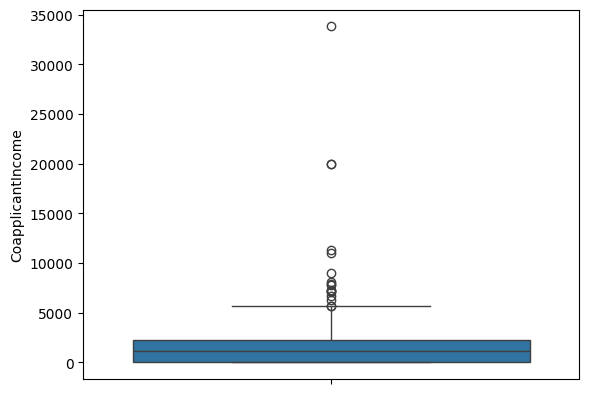

In [33]:
sns.boxplot(df['CoapplicantIncome'])

**Step 3: Data Pre Processing**

Categorical Columns are already encoded

**Step 4: Exploratory Data Analysis**

a. Correlation Matrix

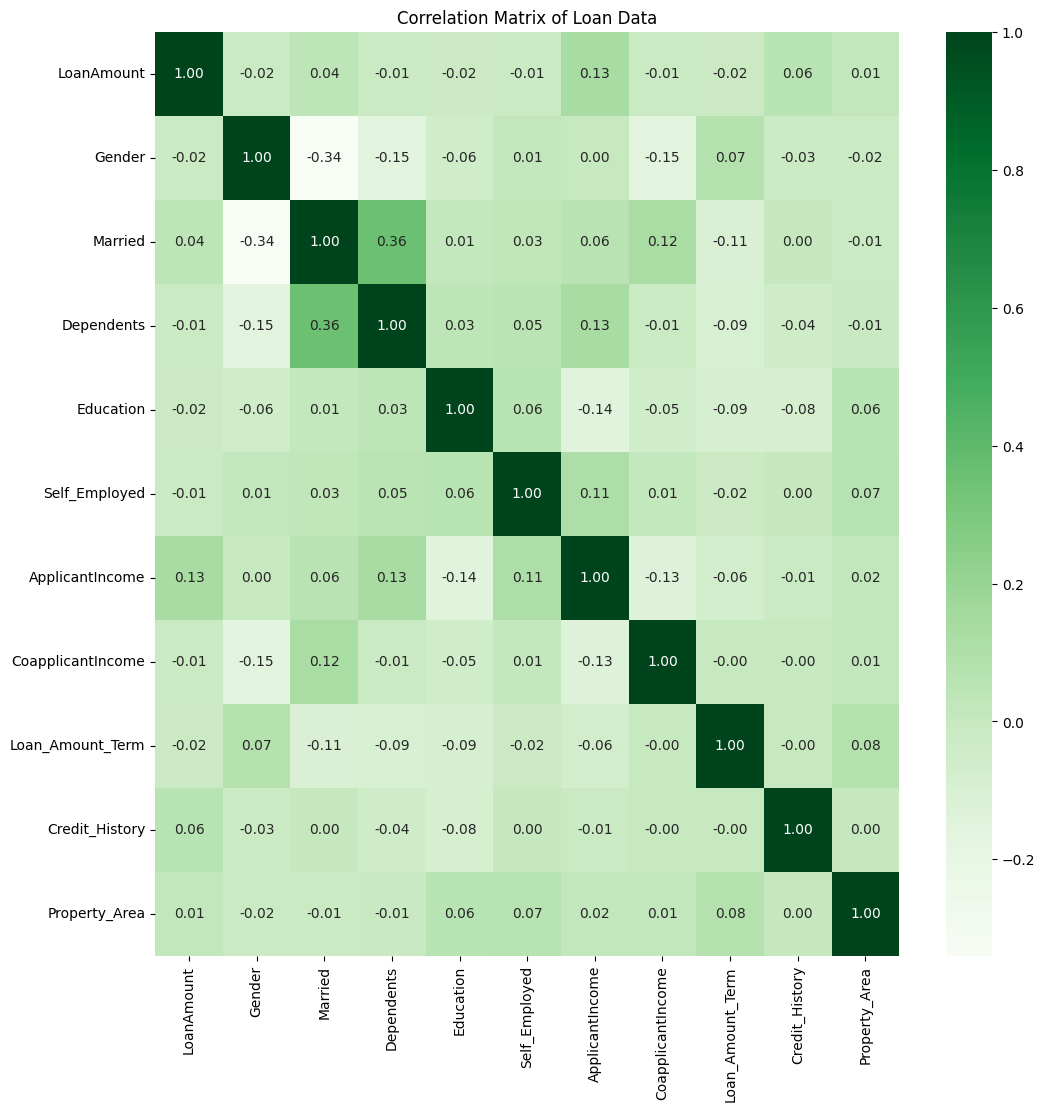

In [34]:
#correlation could not be calculated directly as the loan Id is a non-numeric in nature or as stated in Python a string Value
#so we need to drop the Loan ID Column
correlation_matrix = df.drop('Loan_ID', axis=1).corr()
#explanation of code - drop Loan ID and axis=1 means columns and axis=0 means rows of a dataframe in pandas

# Plot the heatmap
plt.figure(figsize=(12, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='Greens', fmt=".2f")
plt.title('Correlation Matrix of Loan Data')
plt.show()

b. Hypothesis Testing

####1. Whether the loan amount differs with the gender

#### Hypothesis:
#### H0: There is no significant difference in the average loan amount between Male and Female applicants (Mu1=Mu2)

#### Ha: There is a significant difference in the average loan amount between Male and Female applicants (Mu1 <> Mu2)


In [35]:
from scipy import stats

# Separate 'LoanAmount' by 'Gender'
group_male = df[df['Gender'] == 1]['LoanAmount']
group_female = df[df['Gender'] == 2]['LoanAmount'] # Assuming 2 represents female

# Perform independent samples t-test
t_statistic, p_value = stats.ttest_ind(group_male, group_female)

print(f"T-statistic: {t_statistic:.2f}")
print(f"P-value: {p_value:.3f}")

T-statistic: 0.46
P-value: 0.646


Since P Value is more than Alpha(0.05), we retain Null Hypothesis.

Loan Amount does not differ with gender

####2. Whether the loan amount differs with the marital status

#### Hypothesis:
#### H0: There is no significant difference in the average loan amount between unmarried and married applicants (Mu1=Mu2)

#### Ha: There is a significant difference in the average loan amount between unmarried and married applicants (Mu1 <> Mu2)


In [36]:
group_unmarried = df[df['Married'] == 0]['LoanAmount']
group_married = df[df['Married'] == 1]['LoanAmount']

# Perform independent samples t-test
t_statistic, p_value = stats.ttest_ind(group_unmarried, group_married)

print(f"T-statistic: {t_statistic:.2f}")
print(f"P-value: {p_value:.3f}")

T-statistic: -0.86
P-value: 0.392


Since P Value is more than Alpha(0.05), we retain Null Hypothesis.

Loan Amount does not differ with Marital Status

####3. Whether the loan amount differs with the level of education

#### Hypothesis:
#### H0: There is no significant difference in the average loan amount between educated and uneducated appliants (Mu1=Mu2)

#### Ha: There is a significant difference in the average loan amount between educated and uneducated applicants (Mu1 <> Mu2)


In [38]:
# Separate 'Loan Amount' by 'Education'
# Assuming 1 represents Uneducated and 2 represents Educated
group_uneducated = df[df['Education'] == 1]['LoanAmount']
group_educated = df[df['Education'] == 2]['LoanAmount']

# Perform independent samples t-test
t_statistic, p_value = stats.ttest_ind(group_uneducated, group_educated)

print(f"T-statistic: {t_statistic:.2f}")
print(f"P-value: {p_value:.3f}")

T-statistic: 0.54
P-value: 0.589


Since P Value is more than Alpha(0.05), we retain Null Hypothesis.

Loan Amount does not differ with Education Level

####4. Whether the loan amount differs with employment status

#### Hypothesis:
#### H0: There is no significant difference in the average loan amount between Self Employed and Non-Self-Employed applicants (Mu1=Mu2)

#### Ha: There is a significant difference in the average loan amount between Self Employed and Non-Self-Employed applicants (Mu1 <> Mu2)

In [39]:
# Separate 'LoanAmount' by 'Self_Employed'
# Assuming 0 represents Non-Self-Employed and 1 represents Self-Employed
group_non_self_employed = df[df['Self_Employed'] == 0]['LoanAmount']
group_self_employed = df[df['Self_Employed'] == 1]['LoanAmount']

# Perform independent samples t-test
t_statistic, p_value = stats.ttest_ind(group_non_self_employed, group_self_employed)

print(f"T-statistic: {t_statistic:.2f}")
print(f"P-value: {p_value:.3f}")

T-statistic: 0.34
P-value: 0.737


Since P Value is more than Alpha(0.05), we retain Null Hypothesis.

Loan Amount does not differ with Employment Status



####5. Loan Amount varies across different property areas

#### Hypothesis:
#### H0: There is no significant difference in the average loan amount across different property areas (Mu1=Mu2=Mu3)

#### Ha: At least one of them differs (Mu1 <> Mu2<>Mu3)


In [40]:
# Get unique property areas
property_areas = df['Property_Area'].unique()

# Create a list of 'Loan Amount' arrays for each property area
loan_amount_groups = [df['LoanAmount'][df['Property_Area'] == area] for area in property_areas]

# Perform one-way ANOVA test
f_statistic, p_value = stats.f_oneway(*loan_amount_groups)

print(f"F-statistic: {f_statistic:.2f}")
print(f"P-value: {p_value:.3f}")

# Interpret the results
alpha = 0.05 # Significance level
if p_value < alpha:
    print("\nSince the p-value is less than 0.05, we reject the null hypothesis.")
    print("There is a statistically significant difference in Loan Amount across different property areas.")
else:
    print("\nSince the p-value is greater than 0.05, we fail to reject the null hypothesis.")
    print("There is no statistically significant difference in Loan Amount across different property areas.")

F-statistic: 0.13
P-value: 0.882

Since the p-value is greater than 0.05, we fail to reject the null hypothesis.
There is no statistically significant difference in Loan Amount across different property areas.


####6. Loan Amount varies with no of dependents

#### Hypothesis:
#### H0: There is no significant difference in the average loan amount with differenet no of dependents (Mu1=Mu2=Mu3)

#### Ha: At least one of them differs (Mu1 <> Mu2<>Mu3)


In [41]:
# Get unique number of dependents
dependents_count = df['Dependents'].unique()

# Create a list of 'Loan Amount' arrays for each number of dependents
loan_amount_groups = [df['LoanAmount'][df['Dependents'] == count] for count in dependents_count]

# Perform one-way ANOVA test
f_statistic, p_value = stats.f_oneway(*loan_amount_groups)

print(f"F-statistic: {f_statistic:.2f}")
print(f"P-value: {p_value:.3f}")

# Interpret the results
alpha = 0.05 # Significance level
if p_value < alpha:
    print("\nSince the p-value is less than 0.05, we reject the null hypothesis.")
    print("There is a statistically significant difference in Loan Amount across different numbers of dependents.")
else:
    print("\nSince the p-value is greater than 0.05, we fail to reject the null hypothesis.")
    print("There is no statistically significant difference in Loan Amount across different numbers of dependents.")

F-statistic: 0.42
P-value: 0.741

Since the p-value is greater than 0.05, we fail to reject the null hypothesis.
There is no statistically significant difference in Loan Amount across different numbers of dependents.


**Step 5: Fit the Machine Learning Algorithm**

In [43]:
#Defining dependent and independent variables
y = df['LoanAmount']
x = df.drop('LoanAmount', axis=1) #drop Loan Amount and take other columns

In [44]:
y

,LoanAmount
0,120.0
1,128.0
2,66.0
3,120.0
4,141.0
...,...
559,71.0
560,40.0
561,253.0
562,187.0


In [45]:
x

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,Loan_Amount_Term,Credit_History,Property_Area
0,LP001002,1,0,0,1,0,5849,0.0,360,1,1
1,LP001003,1,1,1,1,0,4583,1508.0,360,1,3
2,LP001005,1,1,0,1,1,3000,0.0,360,1,1
3,LP001006,1,1,0,2,0,2583,2358.0,360,1,1
4,LP001008,1,0,0,1,0,6000,0.0,360,1,1
...,...,...,...,...,...,...,...,...,...,...,...
559,LP002978,2,0,0,1,0,2900,0.0,360,1,3
560,LP002979,1,1,3,1,0,4106,0.0,180,1,3
561,LP002983,1,1,1,1,0,8072,240.0,360,1,1
562,LP002984,1,1,2,1,0,7583,0.0,360,1,1


a. Performing Train and Test Split

In [46]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

#test size = 30%, train = 70%
#random state is the seed from where we are splitting the data as we have to start splitting the data from some point.
#42 is the point from where we are splitting the data

In [47]:
x_train

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,Loan_Amount_Term,Credit_History,Property_Area
141,LP001532,1,1,2,2,0,2281,0.0,360,1,3
299,LP002068,1,0,0,1,0,4917,0.0,360,0,3
423,LP002473,1,1,0,1,0,8334,0.0,360,1,2
465,LP002626,1,1,0,1,1,2479,3013.0,360,1,1
19,LP001043,1,1,0,2,0,7660,0.0,360,0,1
...,...,...,...,...,...,...,...,...,...,...,...
71,LP001255,1,0,0,1,0,3750,0.0,480,1,1
106,LP001398,1,0,0,1,0,5050,0.0,360,1,2
270,LP001940,1,1,2,1,0,3153,1560.0,360,1,1
435,LP002519,1,1,3,1,0,4691,0.0,360,1,2


In [48]:
x_test

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,Loan_Amount_Term,Credit_History,Property_Area
537,LP002916,1,1,0,1,0,2297,1522.0,360,1,1
522,LP002842,1,1,1,1,0,3417,1750.0,360,1,1
234,LP001843,1,1,1,2,0,2661,7101.0,180,1,2
523,LP002847,1,1,0,1,0,5116,1451.0,360,0,1
485,LP002714,1,0,1,2,0,2679,1302.0,360,1,2
...,...,...,...,...,...,...,...,...,...,...,...
420,LP002459,1,1,0,1,0,4301,0.0,360,1,1
381,LP002335,2,1,0,2,0,2149,3237.0,360,0,2
518,LP002836,1,0,0,1,0,3333,0.0,360,1,1
403,LP002398,1,0,0,1,0,1926,1851.0,360,1,2


In [49]:

y_train

,LoanAmount
141,113.0
299,130.0
423,160.0
465,188.0
19,104.0
...,...
71,113.0
106,118.0
270,134.0
435,100.0


In [50]:
y_test

,LoanAmount
537,104.0
522,186.0
234,279.0
523,165.0
485,94.0
...,...
420,118.0
381,178.0
518,70.0
403,50.0


b. Fit the Machine Learning Model

In [51]:
import statsmodels.api as sm

# Drop 'Loan_ID' column from x_train as it is a non-numeric identifier
x_train_numeric = x_train.drop('Loan_ID', axis=1)

# Add a constant to the independent variables (x_train_numeric)
x_train1 = sm.add_constant(x_train_numeric)

# Create and fit the OLS (Ordinary Least Squares) model
lr_model = sm.OLS(y_train, x_train1).fit()

# Print the model summary
print(lr_model.summary())

                            OLS Regression Results                            
Dep. Variable:             LoanAmount   R-squared:                       0.039
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     1.562
Date:                Mon, 23 Mar 2026   Prob (F-statistic):              0.116
Time:                        03:47:23   Log-Likelihood:                -3220.0
No. Observations:                 394   AIC:                             6462.
Df Residuals:                     383   BIC:                             6506.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                34.6111    370.81

In the given scenario, there is only one Independent Variable ie Applicant Income whose P Value (0.001) is less than alpha (0.05) and all the other Independent Variables have P Value more than Alpha which means that the Independent Variables are statistically insignificant.
So, we mark the Independent Variable with highest P Value and eliminate them from the data set and check again if the regression equation is sensible till we reach a point where the Independent Variable is statistically significant.



Education has the Highest P-Value, so we drop education and run regression again

In [52]:
x_train_numeric_no_education = x_train_numeric.drop('Education', axis=1)
x_train2 = sm.add_constant(x_train_numeric_no_education)

lr_model_no_education = sm.OLS(y_train, x_train2).fit()
print(lr_model_no_education.summary())

                            OLS Regression Results                            
Dep. Variable:             LoanAmount   R-squared:                       0.039
Model:                            OLS   Adj. R-squared:                  0.017
Method:                 Least Squares   F-statistic:                     1.740
Date:                Mon, 23 Mar 2026   Prob (F-statistic):             0.0783
Time:                        03:47:28   Log-Likelihood:                -3220.0
No. Observations:                 394   AIC:                             6460.
Df Residuals:                     384   BIC:                             6500.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                30.8418    319.66

Co-Applicant Income has the Highest P-Value, so we drop Co-Applicant Income and run regression again

In [53]:
x_train_processed = x_train_numeric_no_education.drop('CoapplicantIncome', axis=1)
x_train3 = sm.add_constant(x_train_processed)

lr_model_processed = sm.OLS(y_train, x_train3).fit()
print(lr_model_processed.summary())

                            OLS Regression Results                            
Dep. Variable:             LoanAmount   R-squared:                       0.039
Model:                            OLS   Adj. R-squared:                  0.019
Method:                 Least Squares   F-statistic:                     1.962
Date:                Mon, 23 Mar 2026   Prob (F-statistic):             0.0500
Time:                        03:47:35   Log-Likelihood:                -3220.0
No. Observations:                 394   AIC:                             6458.
Df Residuals:                     385   BIC:                             6494.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               34.7100    316.164  

Loan Amount Term has the Highest P-Value, so we drop Loan Amount Term and run regression again

In [54]:
x_train_processed2 = x_train_processed.drop('Loan_Amount_Term', axis=1)
x_train4 = sm.add_constant(x_train_processed2)

lr_model_final = sm.OLS(y_train, x_train4).fit()
print(lr_model_final.summary())

                            OLS Regression Results                            
Dep. Variable:             LoanAmount   R-squared:                       0.039
Model:                            OLS   Adj. R-squared:                  0.022
Method:                 Least Squares   F-statistic:                     2.241
Date:                Mon, 23 Mar 2026   Prob (F-statistic):             0.0304
Time:                        03:47:40   Log-Likelihood:                -3220.0
No. Observations:                 394   AIC:                             6456.
Df Residuals:                     386   BIC:                             6488.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              81.6821    238.574     

Property Area has the Highest P-Value, so we drop Property Area and run regression again

In [55]:
x_train_processed3 = x_train_processed2.drop('Property_Area', axis=1)
x_train5 = sm.add_constant(x_train_processed3)

lr_model_processed3 = sm.OLS(y_train, x_train5).fit()
print(lr_model_processed3.summary())

                            OLS Regression Results                            
Dep. Variable:             LoanAmount   R-squared:                       0.039
Model:                            OLS   Adj. R-squared:                  0.024
Method:                 Least Squares   F-statistic:                     2.596
Date:                Mon, 23 Mar 2026   Prob (F-statistic):             0.0177
Time:                        03:47:47   Log-Likelihood:                -3220.1
No. Observations:                 394   AIC:                             6454.
Df Residuals:                     387   BIC:                             6482.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              38.6900    208.903     

Gender has the Highest P-Value, so we drop Gender and run regression again

In [56]:
x_train_processed4 = x_train_processed3.drop('Gender', axis=1)
x_train6 = sm.add_constant(x_train_processed4)

lr_model_processed4 = sm.OLS(y_train, x_train6).fit()
print(lr_model_processed4.summary())

                            OLS Regression Results                            
Dep. Variable:             LoanAmount   R-squared:                       0.038
Model:                            OLS   Adj. R-squared:                  0.026
Method:                 Least Squares   F-statistic:                     3.076
Date:                Mon, 23 Mar 2026   Prob (F-statistic):            0.00977
Time:                        03:47:56   Log-Likelihood:                -3220.2
No. Observations:                 394   AIC:                             6452.
Df Residuals:                     388   BIC:                             6476.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const             -38.3262    132.717     

Dependents has the Highest P-Value, so we drop Dependents and run regression again

In [57]:
x_train_processed5 = x_train_processed4.drop('Dependents', axis=1)
x_train7 = sm.add_constant(x_train_processed5)

lr_model_processed5 = sm.OLS(y_train, x_train7).fit()
print(lr_model_processed5.summary())

                            OLS Regression Results                            
Dep. Variable:             LoanAmount   R-squared:                       0.037
Model:                            OLS   Adj. R-squared:                  0.027
Method:                 Least Squares   F-statistic:                     3.686
Date:                Mon, 23 Mar 2026   Prob (F-statistic):            0.00584
Time:                        03:48:03   Log-Likelihood:                -3220.5
No. Observations:                 394   AIC:                             6451.
Df Residuals:                     389   BIC:                             6471.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const             -45.2770    132.378     

Self Employed has the Highest P-Value, so we drop Self Employed and run regression again

In [58]:
x_train_processed6 = x_train_processed5.drop('Self_Employed', axis=1)
x_train8 = sm.add_constant(x_train_processed6)

lr_model_processed6 = sm.OLS(y_train, x_train8).fit()
print(lr_model_processed6.summary())

                            OLS Regression Results                            
Dep. Variable:             LoanAmount   R-squared:                       0.034
Model:                            OLS   Adj. R-squared:                  0.027
Method:                 Least Squares   F-statistic:                     4.626
Date:                Mon, 23 Mar 2026   Prob (F-statistic):            0.00342
Time:                        03:48:06   Log-Likelihood:                -3221.0
No. Observations:                 394   AIC:                             6450.
Df Residuals:                     390   BIC:                             6466.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const             -54.5272    131.984     

Married has the Highest P-Value, so we drop Married and run regression again

In [59]:
x_train_processed7 = x_train_processed6.drop('Married', axis=1)
x_train9 = sm.add_constant(x_train_processed7)

lr_model_processed7 = sm.OLS(y_train, x_train9).fit()
print(lr_model_processed7.summary())

                            OLS Regression Results                            
Dep. Variable:             LoanAmount   R-squared:                       0.032
Model:                            OLS   Adj. R-squared:                  0.027
Method:                 Least Squares   F-statistic:                     6.428
Date:                Mon, 23 Mar 2026   Prob (F-statistic):            0.00179
Time:                        03:48:07   Log-Likelihood:                -3221.5
No. Observations:                 394   AIC:                             6449.
Df Residuals:                     391   BIC:                             6461.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -2.2100    121.393     

Credit History has the Highest P-Value, so we drop Credit History and run regression again

In [60]:
x_train_processed8 = x_train_processed7.drop('Credit_History', axis=1)
x_train_final = sm.add_constant(x_train_processed8)

lr_model_final = sm.OLS(y_train, x_train_final).fit()
print(lr_model_final.summary())

                            OLS Regression Results                            
Dep. Variable:             LoanAmount   R-squared:                       0.029
Model:                            OLS   Adj. R-squared:                  0.027
Method:                 Least Squares   F-statistic:                     11.75
Date:                Mon, 23 Mar 2026   Prob (F-statistic):           0.000672
Time:                        03:48:09   Log-Likelihood:                -3222.0
No. Observations:                 394   AIC:                             6448.
Df Residuals:                     392   BIC:                             6456.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const             107.4058     61.804     

We can find that after elimination of all the independent variables whose p values are greater than alpha (0.05), only applicant income has P value less than alpha (0.05). It is the only Independent Variable which is statistically significant.


From the above output:

1. All the independent variables are found to be significant since the p-value is less than 0.05

2. Overall regression equation is also significant since the probability of F Statistics is also less than 0.05

3. Interpreting R Square = 0.029 which means that only 2.9% variation in the estimating the loan amount is explained by these significant independent variables

**Step 6: Model Diagnostics**

In order to conclude or use this ML Equation on test data, the model has to fulfill model diagnostics of MLR

1. Residuals should be normally distributed

2. Homoscedasticity

3. No Multicollinearity - extract Variance Inflation Factor(VIF)


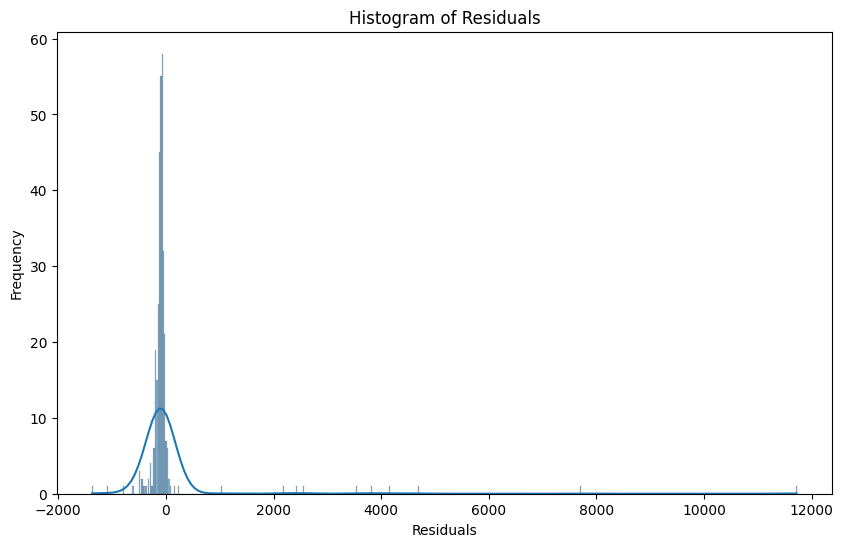

In [61]:
#Checking if Residual Values are normally distributed
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the residuals from the latest model
residuals = lr_model_final.resid

# Plot a histogram of the residuals
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

The histogram of residuals shows a highly skewed distribution, with a very long tail to the right (positive skewness).

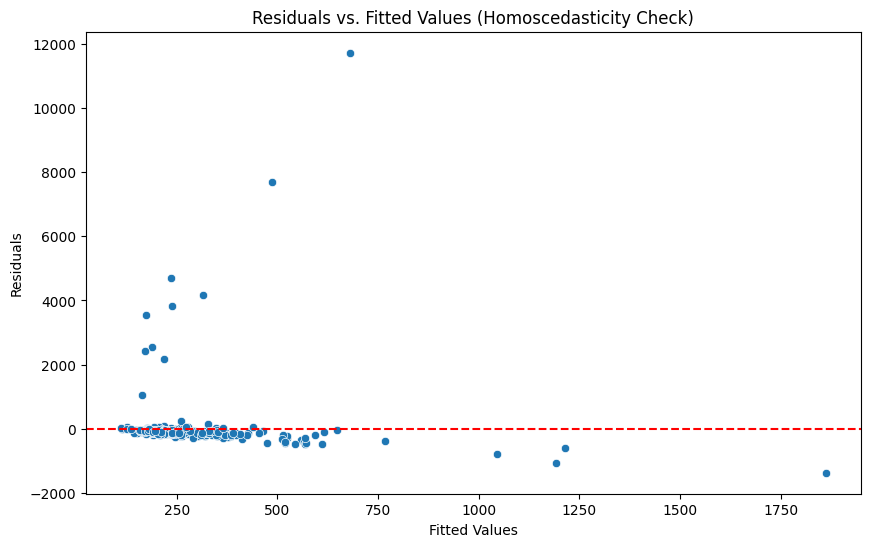

In [62]:
#Checking for Homoscedasticity
import matplotlib.pyplot as plt
import seaborn as sns

# Get predicted values from the model
predicted_values = lr_model_final.predict(x_train_final)

# Plot residuals vs. predicted values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=predicted_values, y=residuals)
plt.axhline(y=0, color='r', linestyle='--') # Add a horizontal line at y=0
plt.title('Residuals vs. Fitted Values (Homoscedasticity Check)')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()

The variance of residuals of error is taking a funnel shape , so we can use WHITE TEST(If the data is numeric in nature) to confirm whether the ML model fulfills the homoscedasticity principle.

In [63]:
#White Test for Homoscedasticity
from statsmodels.stats.api import het_white

# Perform White's test for homoscedasticity
# The test takes residuals and the independent variables (including constant for robust tests)
# The original independent variables used for the final model were x_train_new_2
# However, for het_white, the exog argument should also contain the constant term

white_test_results = het_white(lr_model_final.resid, lr_model_final.model.exog)

# The results are (LM statistic, LM p-value, F-statistic, F p-value)
lm_statistic, lm_p_value, f_statistic, f_p_value = white_test_results

print(f"White's Test LM Statistic: {lm_statistic:.2f}")
print(f"White's Test LM P-value: {lm_p_value:.3f}")
print(f"White's Test F-Statistic: {f_statistic:.2f}")
print(f"White's Test F P-value: {f_p_value:.3f}")

# Interpret the results
alpha = 0.05 # Significance level
if lm_p_value < alpha:
    print("\nSince the LM p-value is less than 0.05, we reject the null hypothesis.")
    print("There is evidence of heteroscedasticity.")
else:
    print("\nSince the LM p-value is greater than 0.05, we fail to reject the null hypothesis.")
    print("There is no sufficient evidence of heteroscedasticity (homoscedasticity assumed).")

White's Test LM Statistic: 16.20
White's Test LM P-value: 0.000
White's Test F-Statistic: 8.38
White's Test F P-value: 0.000

Since the LM p-value is less than 0.05, we reject the null hypothesis.
There is evidence of heteroscedasticity.


Through WHITE TEST, it is proven that the variance of the residuals are not constant, hence do not fulfill homoscedasticity principle.

One of the reasons for heteroscedasticity could be because of presence of outliers.

In [64]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Independent variables without the constant term. We use x_train_numeric which contains all original independent variables.
x_no_const = x_train_numeric

# Create a DataFrame to store VIF results
vif_data = pd.DataFrame()
vif_data["feature"] = x_no_const.columns
vif_data["VIF"] = [variance_inflation_factor(x_no_const.values, i) for i in range(x_no_const.shape[1])]

# Sort the VIF values for better readability
vif_data = vif_data.sort_values(by="VIF", ascending=False)

display(vif_data)

,feature,VIF
7,Loan_Amount_Term,17.417211
0,Gender,9.111658
3,Education,7.910521
9,Property_Area,7.387571
8,Credit_History,6.227851
1,Married,3.133650
5,ApplicantIncome,2.135563
2,Dependents,1.744009
6,CoapplicantIncome,1.447331
4,Self_Employed,1.265390


The VIF analysis reveals significant multicollinearity among several independent variables, especially 'Loan_Amount_Term' and 'Gender'. This indicates that these predictors are highly correlated with each other, which can compromise the reliability of the regression model's coefficients.

Since the Model does not fulfill all the 3 assumptions, we can conclude that the Model is unfit for prediction
